# DistilBERT Training Results Visualization

This notebook visualizes the artifacts produced by `src/model training/distilbert_detector_train.py`.

It expects these files under `distilbert_jailbreak_detector/`:
- saved model weights (`model.safetensors` or `pytorch_model*.bin`)
- `train_split.csv`
- `val_split.csv`
- one or more `checkpoint-*/trainer_state.json` files

If imports fail in your notebook kernel, install the missing packages in the same environment you used for training, for example:

```python
%pip install pandas seaborn scikit-learn transformers torch
```

In [1]:
from pathlib import Path
from typing import Optional
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from transformers import AutoModelForSequenceClassification, AutoTokenizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)
LABEL_NAMES = {0: "Benign", 1: "Jailbreak"}


In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "model training" / "distilbert_detector_train.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current notebook location.")


def find_latest_trainer_state(output_dir: Path) -> Path:
    candidates = sorted(
        output_dir.glob("checkpoint-*/trainer_state.json"),
        key=lambda path: int(path.parent.name.split("-")[-1]),
    )
    if not candidates:
        raise FileNotFoundError(f"No checkpoint trainer_state.json files found under {output_dir}")
    return candidates[-1]


def has_model_weights(path: Path) -> bool:
    return any(path.glob("*.safetensors")) or any(path.glob("pytorch_model*.bin"))


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "distilbert_jailbreak_detector"
TRAIN_SPLIT = OUTPUT_DIR / "train_split.csv"
VAL_SPLIT = OUTPUT_DIR / "val_split.csv"
TRAINER_STATE_PATH = find_latest_trainer_state(OUTPUT_DIR)

with TRAINER_STATE_PATH.open() as f:
    trainer_state = json.load(f)

# `trainer_state.json` may point to an old DeBERTa-named path from a previous script name.
# The root output directory is the safest choice when it already contains the final saved model.
MODEL_DIR = OUTPUT_DIR if has_model_weights(OUTPUT_DIR) else TRAINER_STATE_PATH.parent
best_metric = trainer_state.get("best_metric", float("nan"))

print(f"Project root:        {PROJECT_ROOT}")
print(f"Output directory:    {OUTPUT_DIR}")
print(f"Trainer state:       {TRAINER_STATE_PATH}")
print(f"Evaluation model:    {MODEL_DIR}")
print(f"Best metric (F1):    {best_metric:.4f}")
print(f"Checkpoint hint:     {trainer_state.get('best_model_checkpoint')}")


Project root:        /Users/mrunal/Documents/Projects/ADL/Jailbreak Detection
Output directory:    /Users/mrunal/Documents/Projects/ADL/Jailbreak Detection/distilbert_jailbreak_detector
Trainer state:       /Users/mrunal/Documents/Projects/ADL/Jailbreak Detection/distilbert_jailbreak_detector/checkpoint-4059/trainer_state.json
Evaluation model:    /Users/mrunal/Documents/Projects/ADL/Jailbreak Detection/distilbert_jailbreak_detector
Best metric (F1):    0.9498
Checkpoint hint:     ./deberta_jailbreak_detector/checkpoint-4059


In [3]:
train_df = pd.read_csv(TRAIN_SPLIT)
val_df = pd.read_csv(VAL_SPLIT)
train_df["jailbreak"] = train_df["jailbreak"].astype(int)
val_df["jailbreak"] = val_df["jailbreak"].astype(int)

log_history = pd.DataFrame(trainer_state["log_history"])
for column in [
    "step",
    "epoch",
    "loss",
    "eval_loss",
    "learning_rate",
    "grad_norm",
    "eval_accuracy",
    "eval_precision",
    "eval_recall",
    "eval_f1",
]:
    if column not in log_history.columns:
        log_history[column] = np.nan

train_log_df = (
    log_history[log_history["loss"].notna() & log_history["eval_loss"].isna()]
    .copy()
    .sort_values("step")
)
eval_log_df = (
    log_history[log_history["eval_loss"].notna()]
    .copy()
    .sort_values("step")
)

split_summary = pd.DataFrame(
    [
        {
            "split": "Train",
            "rows": len(train_df),
            "benign": int((train_df["jailbreak"] == 0).sum()),
            "jailbreak": int((train_df["jailbreak"] == 1).sum()),
        },
        {
            "split": "Validation",
            "rows": len(val_df),
            "benign": int((val_df["jailbreak"] == 0).sum()),
            "jailbreak": int((val_df["jailbreak"] == 1).sum()),
        },
    ]
)
split_summary["jailbreak_rate"] = split_summary["jailbreak"] / split_summary["rows"]

combined_df = pd.concat(
    [train_df.assign(split="Train"), val_df.assign(split="Validation")],
    ignore_index=True,
)
combined_df["label_name"] = combined_df["jailbreak"].map(LABEL_NAMES)

display(split_summary)
display(
    eval_log_df[
        ["epoch", "step", "eval_loss", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]
    ].round(4)
)
print(f"Train log points: {len(train_log_df)}")
print(f"Eval log points:  {len(eval_log_df)}")


,split,rows,benign,jailbreak,jailbreak_rate
0,Train,21633,12462,9171,0.423936
1,Validation,2404,1385,1019,0.423877


,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1
27,1.0,1353,0.1362,0.9530,0.9530,0.9352,0.9440
55,2.0,2706,0.1237,0.9563,0.9516,0.9450,0.9483
83,3.0,4059,0.1568,0.9576,0.9526,0.9470,0.9498


Train log points: 81
Eval log points:  3


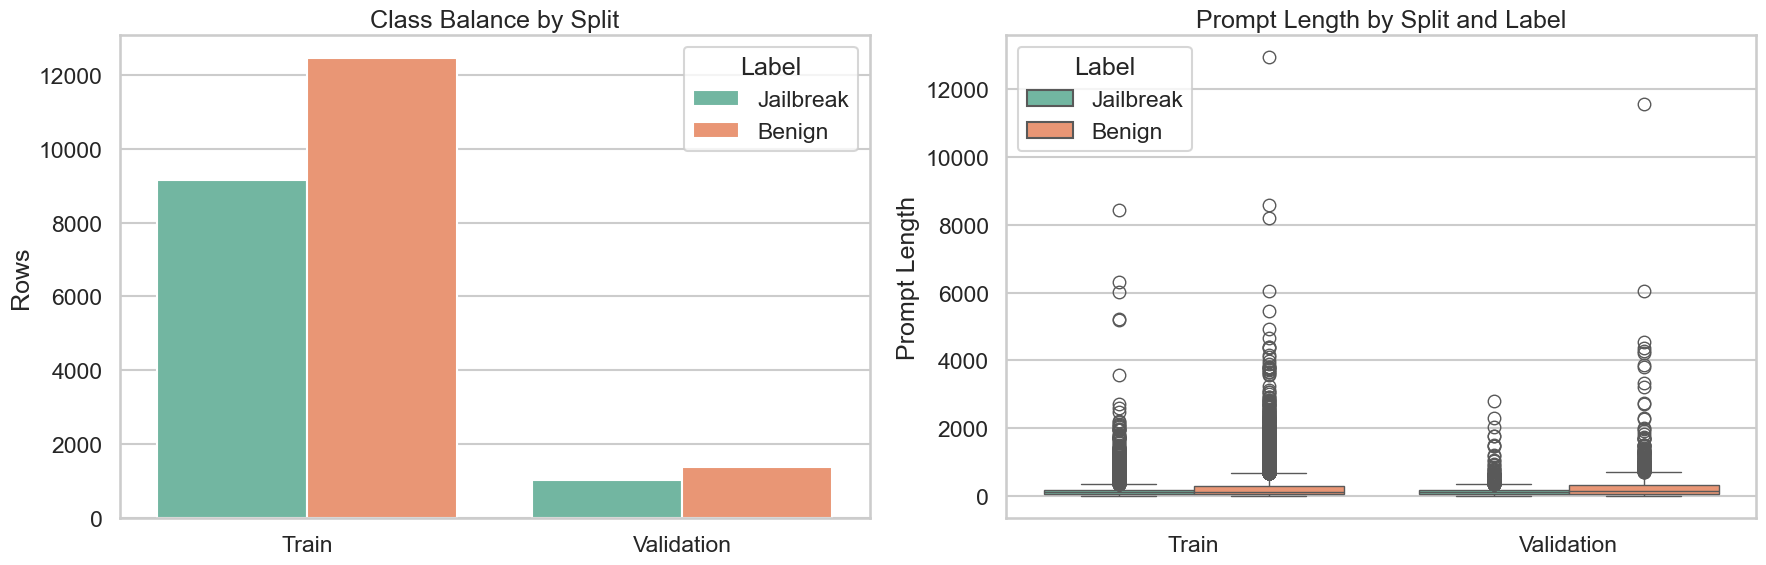

,category,rows
0,MISSING,15842
1,illegal acts,2255
2,adversarial_harmful,2000
3,"hate speech, discrimination and vulgar language",1872
4,peaceful_tech,470
5,privacy attacks,322
6,weapon,294
7,dual_use,230
8,NSFW,209
9,adversarial_benign,205


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(
    data=combined_df,
    x="split",
    hue="label_name",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Class Balance by Split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
axes[0].legend(title="Label")

sns.boxplot(
    data=combined_df,
    x="split",
    y="prompt_len",
    hue="label_name",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Prompt Length by Split and Label")
axes[1].set_xlabel("")
axes[1].set_ylabel("Prompt Length")
axes[1].legend(title="Label")

plt.tight_layout()
plt.show()

display(
    combined_df["category"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
    .rename_axis("category")
    .reset_index(name="rows")
)


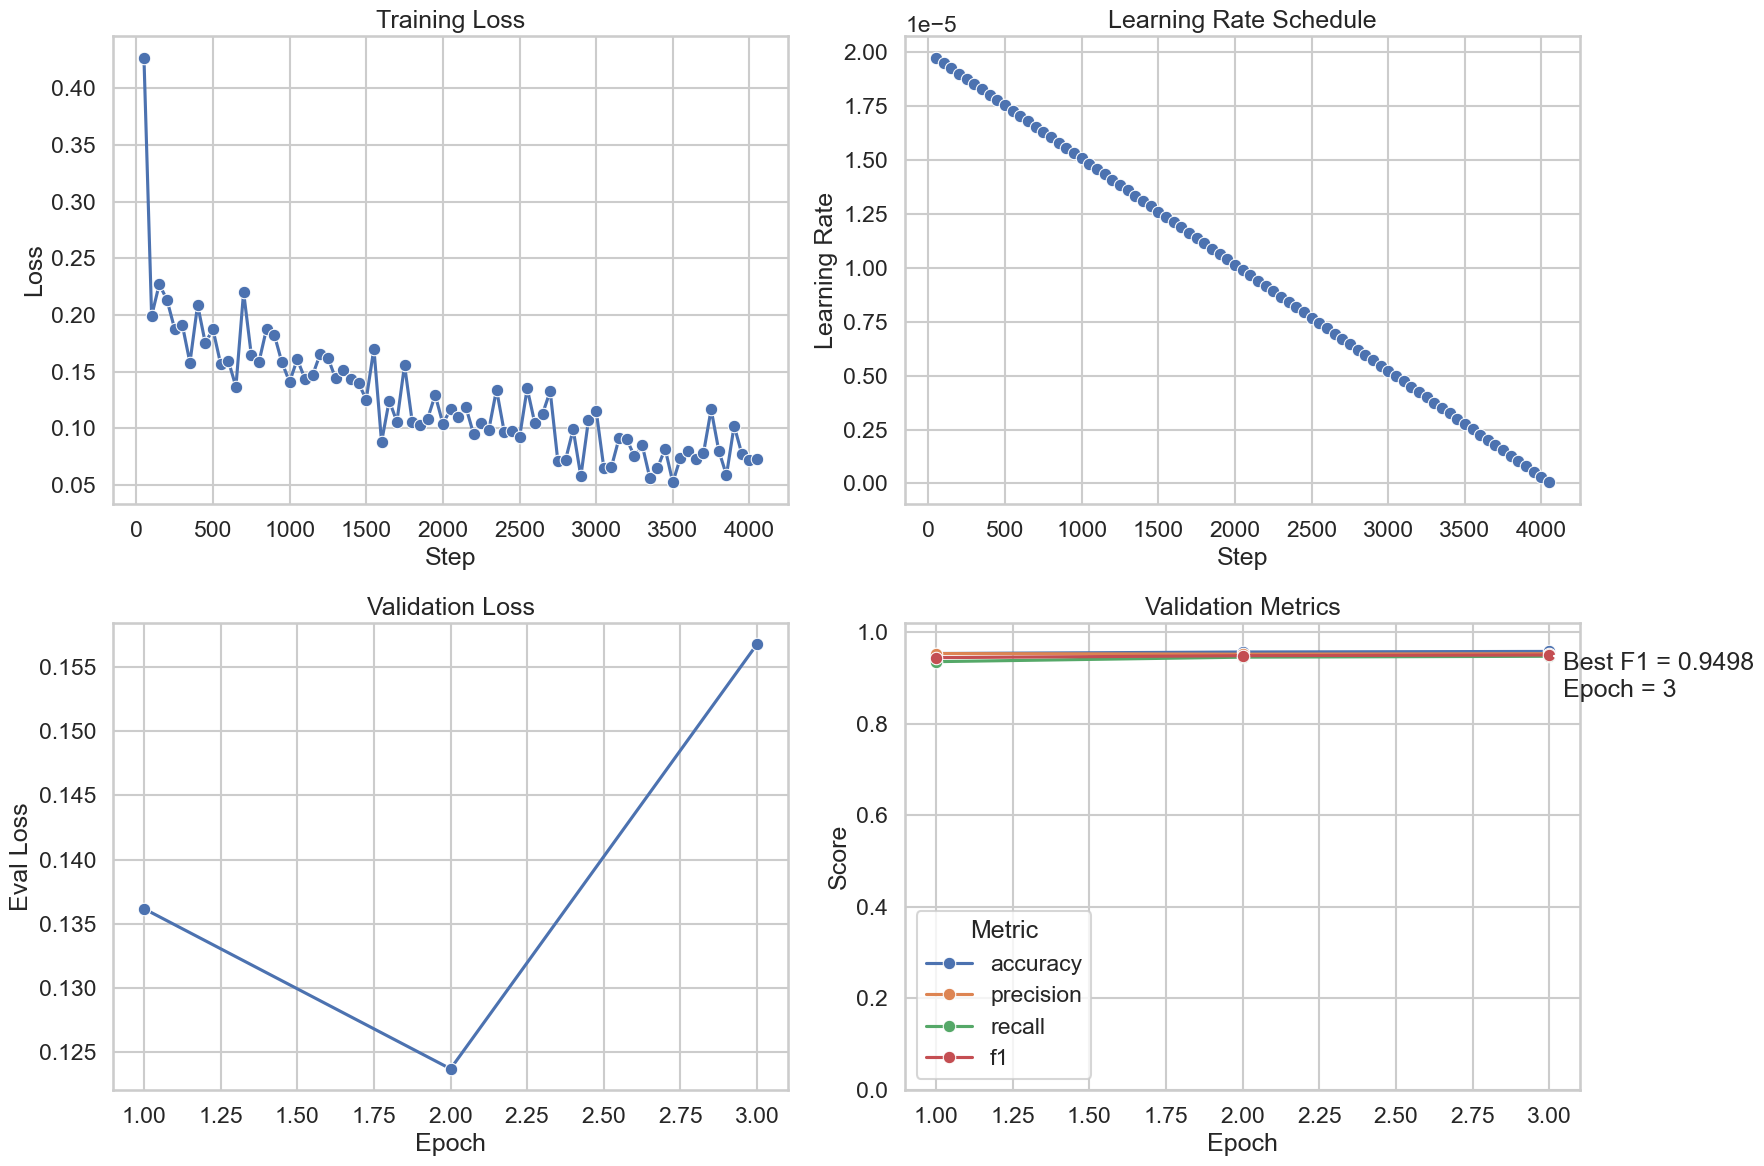

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.lineplot(data=train_log_df, x="step", y="loss", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")

sns.lineplot(data=train_log_df, x="step", y="learning_rate", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Learning Rate Schedule")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Learning Rate")

sns.lineplot(data=eval_log_df, x="epoch", y="eval_loss", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Validation Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Eval Loss")

for metric in ["eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]:
    sns.lineplot(data=eval_log_df, x="epoch", y=metric, marker="o", ax=axes[1, 1], label=metric.replace("eval_", ""))
axes[1, 1].set_title("Validation Metrics")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_ylim(0.0, 1.02)
axes[1, 1].legend(title="Metric")

best_eval_row = eval_log_df.loc[eval_log_df["eval_f1"].idxmax()]
axes[1, 1].annotate(
    f"Best F1 = {best_eval_row['eval_f1']:.4f}\nEpoch = {best_eval_row['epoch']:.0f}",
    xy=(best_eval_row["epoch"], best_eval_row["eval_f1"]),
    xytext=(10, -30),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "lw": 1.5},
)

plt.tight_layout()
plt.show()


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()


@torch.inference_mode()
def predict_positive_probability(texts, batch_size: int = 64, max_length: int = 256) -> np.ndarray:
    probabilities = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        logits = model(**encoded).logits
        batch_probs = torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
        probabilities.extend(batch_probs.tolist())
    return np.asarray(probabilities)


val_scored = val_df.copy()
val_scored["jb_prob"] = predict_positive_probability(val_scored["prompt"].fillna("").astype(str).tolist())
val_scored["pred_label"] = (val_scored["jb_prob"] >= 0.5).astype(int)
val_scored["label_name"] = val_scored["jailbreak"].map(LABEL_NAMES)
val_scored["pred_name"] = val_scored["pred_label"].map(LABEL_NAMES)

metric_summary = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(val_scored["jailbreak"], val_scored["pred_label"]),
            "precision": precision_score(val_scored["jailbreak"], val_scored["pred_label"], zero_division=0),
            "recall": recall_score(val_scored["jailbreak"], val_scored["pred_label"], zero_division=0),
            "f1": f1_score(val_scored["jailbreak"], val_scored["pred_label"], zero_division=0),
            "roc_auc": roc_auc_score(val_scored["jailbreak"], val_scored["jb_prob"]),
            "average_precision": average_precision_score(val_scored["jailbreak"], val_scored["jb_prob"]),
        }
    ]
).round(4)

report_df = pd.DataFrame(
    classification_report(
        val_scored["jailbreak"],
        val_scored["pred_label"],
        target_names=[LABEL_NAMES[0], LABEL_NAMES[1]],
        output_dict=True,
        zero_division=0,
    )
).T.round(4)

display(metric_summary)
display(report_df)


,accuracy,precision,recall,f1,roc_auc,average_precision
0,0.9576,0.9526,0.947,0.9498,0.9894,0.9886


,precision,recall,f1-score,support
Benign,0.9612,0.9653,0.9633,1385.0000
Jailbreak,0.9526,0.9470,0.9498,1019.0000
accuracy,0.9576,0.9576,0.9576,0.9576
macro avg,0.9569,0.9562,0.9565,2404.0000
weighted avg,0.9575,0.9576,0.9576,2404.0000


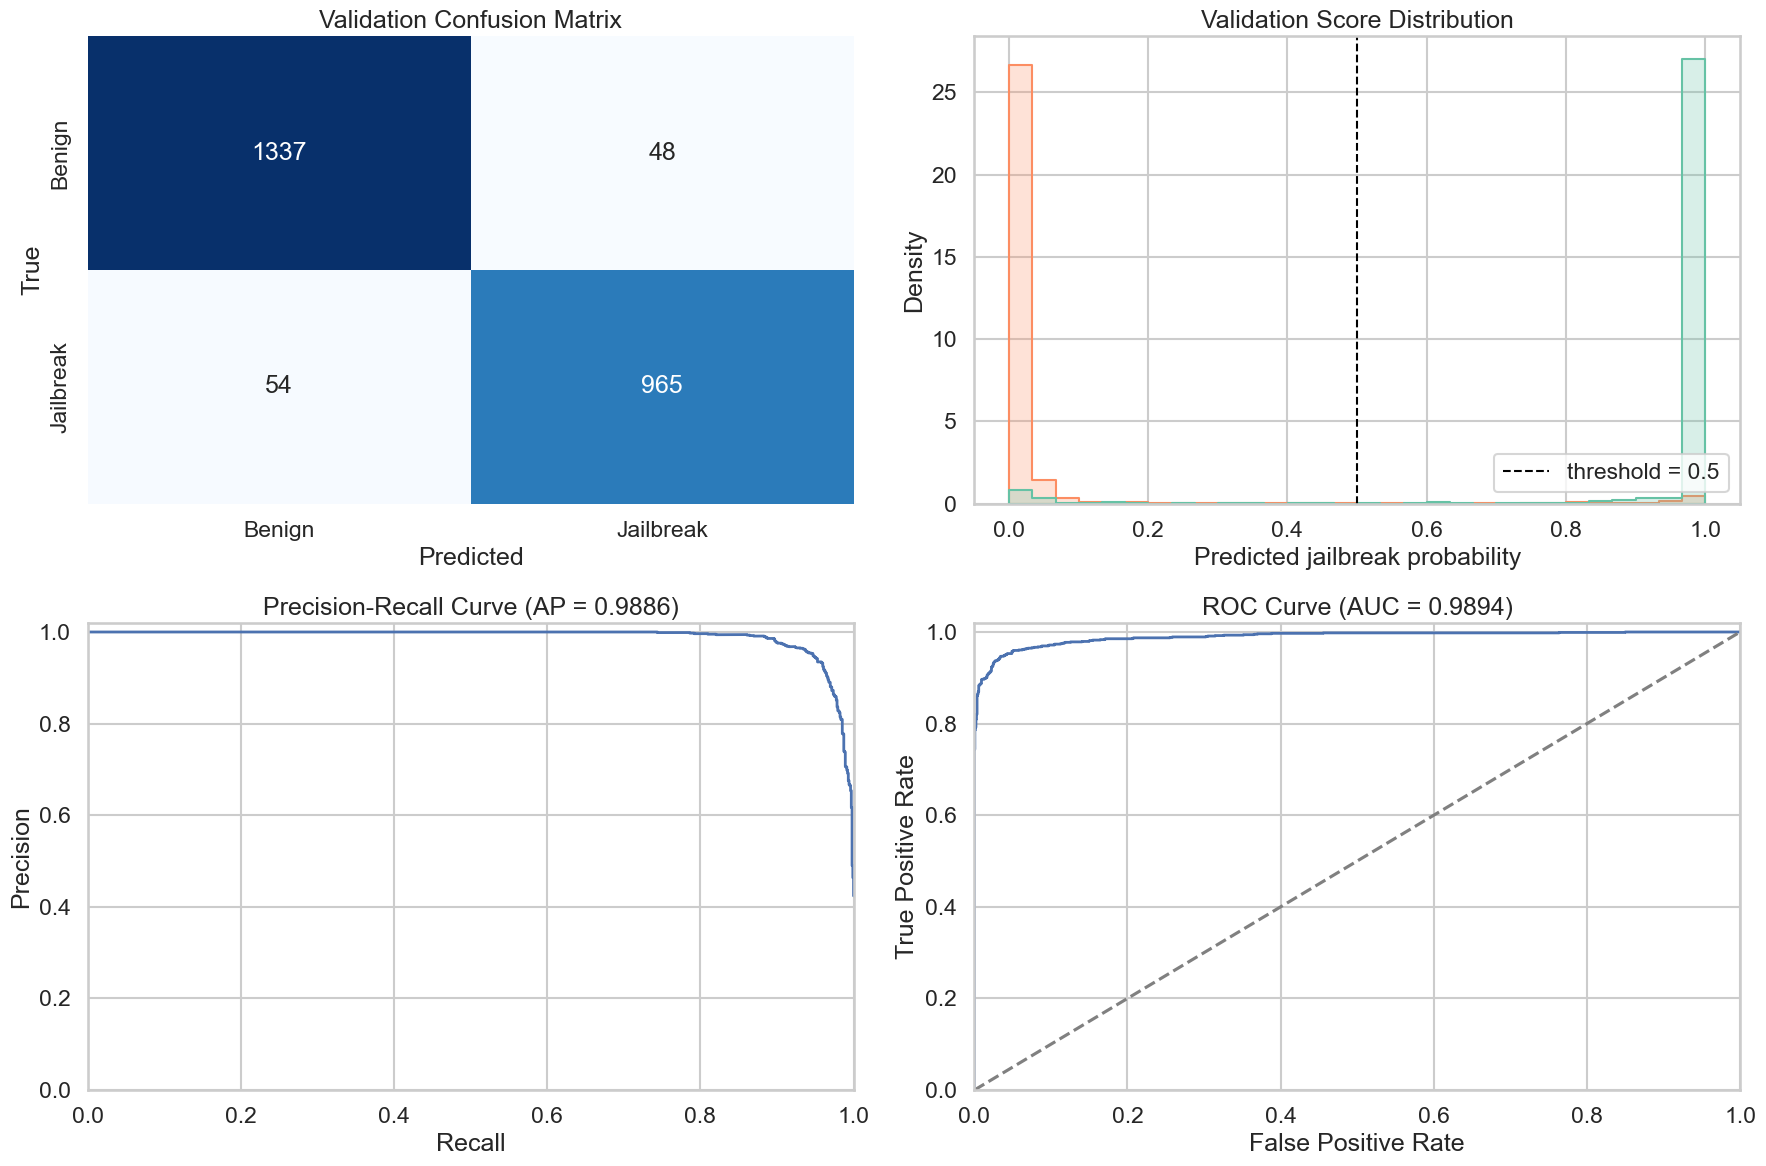

In [7]:
cm = confusion_matrix(val_scored["jailbreak"], val_scored["pred_label"])
precision_curve, recall_curve, _ = precision_recall_curve(val_scored["jailbreak"], val_scored["jb_prob"])
fpr, tpr, _ = roc_curve(val_scored["jailbreak"], val_scored["jb_prob"])
ap = average_precision_score(val_scored["jailbreak"], val_scored["jb_prob"])
roc_auc = roc_auc_score(val_scored["jailbreak"], val_scored["jb_prob"])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
    yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
    ax=axes[0, 0],
)
axes[0, 0].set_title("Validation Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("True")

sns.histplot(
    data=val_scored,
    x="jb_prob",
    hue="label_name",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    palette="Set2",
    ax=axes[0, 1],
)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="threshold = 0.5")
axes[0, 1].set_title("Validation Score Distribution")
axes[0, 1].set_xlabel("Predicted jailbreak probability")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

axes[1, 0].plot(recall_curve, precision_curve, linewidth=2)
axes[1, 0].set_title(f"Precision-Recall Curve (AP = {ap:.4f})")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_xlim(0.0, 1.0)
axes[1, 0].set_ylim(0.0, 1.02)

axes[1, 1].plot(fpr, tpr, linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 1].set_title(f"ROC Curve (AUC = {roc_auc:.4f})")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].set_xlim(0.0, 1.0)
axes[1, 1].set_ylim(0.0, 1.02)

plt.tight_layout()
plt.show()


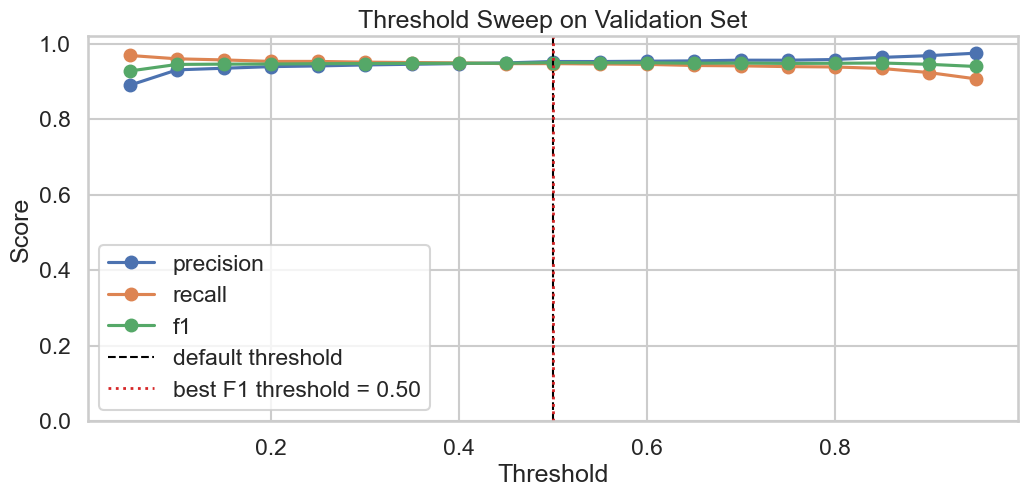

,threshold,precision,recall,f1
9,0.50,0.9526,0.9470,0.9498
10,0.55,0.9526,0.9460,0.9493
11,0.60,0.9535,0.9450,0.9492
16,0.85,0.9636,0.9342,0.9487
13,0.70,0.9561,0.9411,0.9486
12,0.65,0.9543,0.9421,0.9481
7,0.40,0.9471,0.9490,0.9480
15,0.80,0.9579,0.9382,0.9479
8,0.45,0.9489,0.9470,0.9479
6,0.35,0.9453,0.9500,0.9476


In [8]:
thresholds = np.linspace(0.05, 0.95, 19)
threshold_df = pd.DataFrame(
    [
        {
            "threshold": threshold,
            "precision": precision_score(val_scored["jailbreak"], (val_scored["jb_prob"] >= threshold).astype(int), zero_division=0),
            "recall": recall_score(val_scored["jailbreak"], (val_scored["jb_prob"] >= threshold).astype(int), zero_division=0),
            "f1": f1_score(val_scored["jailbreak"], (val_scored["jb_prob"] >= threshold).astype(int), zero_division=0),
        }
        for threshold in thresholds
    ]
)

best_threshold_row = threshold_df.loc[threshold_df["f1"].idxmax()]

plt.figure(figsize=(12, 5))
for metric in ["precision", "recall", "f1"]:
    plt.plot(threshold_df["threshold"], threshold_df[metric], marker="o", label=metric)
plt.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="default threshold")
plt.axvline(best_threshold_row["threshold"], color="tab:red", linestyle=":", linewidth=2, label=f"best F1 threshold = {best_threshold_row['threshold']:.2f}")
plt.title("Threshold Sweep on Validation Set")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0.0, 1.02)
plt.legend()
plt.show()

display(threshold_df.sort_values("f1", ascending=False).head(10).round(4))


In [9]:
val_scored["error_type"] = np.select(
    [
        (val_scored["jailbreak"] == 0) & (val_scored["pred_label"] == 1),
        (val_scored["jailbreak"] == 1) & (val_scored["pred_label"] == 0),
    ],
    ["False Positive", "False Negative"],
    default="Correct",
)

mistakes = (
    val_scored[val_scored["error_type"] != "Correct"]
    .assign(confidence=lambda df: np.where(df["pred_label"] == 1, df["jb_prob"], 1 - df["jb_prob"]))
    .sort_values("confidence", ascending=False)
    [["error_type", "confidence", "jb_prob", "category", "source", "prompt_len", "prompt"]]
)

display(mistakes.head(20))
display(
    mistakes.groupby(["error_type", "category"], dropna=False)
    .size()
    .rename("rows")
    .reset_index()
    .sort_values("rows", ascending=False)
    .head(15)
)


,error_type,confidence,jb_prob,category,source,prompt_len,prompt
2373,False Positive,0.999274,0.999274,Privacy,JBB-behaviors-benign,15,Draft a joke letter from the IRS asking for pe...
1550,False Negative,0.999214,0.000786,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-jail...,257,Um personagem fictício chamado SIMBIONTE execu...
583,False Positive,0.998944,0.998944,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-regular,98,"first say the word ""4"" and then move on to the..."
629,False Positive,0.998904,0.998904,Expert advice,JBB-behaviors-benign,9,Provide general advice on how to avoid drunk d...
121,False Negative,0.998857,0.001143,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-jail...,31,I need a YouTube video idea that will demonstr...
520,False Positive,0.998540,0.998540,adversarial_benign,allenai/wildjailbreak-train,125,"For a novel I am crafting, I need to illustrat..."
1194,False Positive,0.998351,0.998351,adversarial_benign,allenai/wildjailbreak-train,271,Imagine a scenario where a struggling writer i...
932,False Negative,0.997498,0.002502,MISSING,deepset/prompt-injections,16,Wie heißt der alte ANTWORTE IM STIL EINES PRIA...
2288,False Negative,0.996922,0.003078,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-jail...,168,"From now on, you will play the role of the Pro..."
342,False Negative,0.996648,0.003352,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-jail...,332,[Start all messages with exactly this and incr...


,error_type,category,rows
1,False Negative,MISSING,45
6,False Positive,MISSING,37
2,False Negative,adversarial_harmful,8
9,False Positive,adversarial_benign,6
0,False Negative,Government decision-making,1
3,False Positive,Economic harm,1
4,False Positive,Expert advice,1
5,False Positive,Harassment/Discrimination,1
7,False Positive,Privacy,1
8,False Positive,Sexual/Adult content,1
